In [ ]:
# A/B Product Experiment Analysis

# This project is a simulation of an A/B test which compares two different versions of a product feature.  The goal is to find which version generates a higher user conversion rate through the use of data analysis and Python techniques.

#Version A represents the original design
#Version B represents a new product feature


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Generate Experiment Dataset

# The upcoming section creates a simulated dataset of 1000 assigned at random to either group A or group B.


In [ ]:
np.random.seed(42)

users = 1000

data = pd.DataFrame({
    "user_id": range(users),
    "group": np.random.choice(["A", "B"], users),
})

# simulation of conversion behavior
data["converted"] = data["group"].apply(
    lambda x: np.random.binomial(1, 0.12) if x == "A" else np.random.binomial(1, 0.16)
)

data.head()

,user_id,group,converted
0,0,A,0
1,1,B,0
2,2,A,0
3,3,A,0
4,4,A,0


In [ ]:
## Conversion Rate Analysis

# The average conversion rate is then calcuated for each test group.

In [ ]:
data.groupby("group")["converted"].mean()

,converted
group,
A,0.108163
B,0.168627


In [ ]:
## Visualization of A/B Test Results

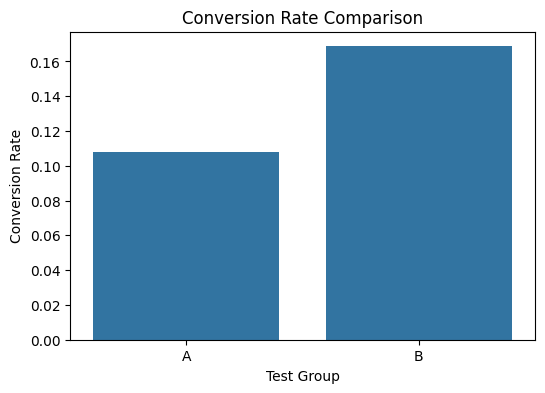

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(x=conversion_rates.index, y=conversion_rates.values)

plt.title("Conversion Rate Comparison")
plt.ylabel("Conversion Rate")
plt.xlabel("Test Group")

plt.show()

In [ ]:
## Statistical Significance Test

#In order to determine the difference between both groups is significant, we must perform a two-proportion z-test


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# conversions
conversions = data.groupby("group")["converted"].sum()

# total users per group
n = data.groupby("group")["converted"].count()

stat, p_value = proportions_ztest(conversions, n)

print("Z-statistic:", stat)
print("P-value:", p_value)

Z-statistic: -2.7629457673344504
P-value: 0.005728228334356762


In [ ]:
## Conclusion

# The analysis above displays Version B having a higher conversion rate than Version A.
# If the P-value is below 0.05, the difference between the groups is statisically signifcant.
# This implies the modified product design has higher user engagement